<a href="https://colab.research.google.com/github/lgiraldo9/Attention_Control/blob/main/inteligencia_artificial_ejercici_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import tensorflow as tf

In [2]:
#descargar las imagenes de tensorflow
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Datos para el entrenamiento",X_train.shape, y_train.shape)
print("Datos para la prueba",X_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos para el entrenamiento (60000, 28, 28) (60000,)
Datos para la prueba (10000, 28, 28) (10000,)


In [8]:
#mostramos la imagen por medio del indice
X_train[20]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  38, 190,  25,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  13,  25,  10,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 112, 252, 125,   4,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 132, 252, 113,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  61, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 132, 252, 240,  79,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  84, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 132, 252, 252, 238,  52,   0,   0,   0,   0,   0,
          0,   0,   0,  12, 198, 252, 252, 122,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  99, 252, 252, 252, 181,  17,   0,   0,   0,   0,
          0,   0,   0,  49, 252, 252, 252, 122,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   3, 125, 252, 252, 252, 100,   0,   0,   0,   0,
          0,   0,   0,  26, 218, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  15, 216, 252, 252, 207,  19,   0,   0,   0,
          0,   0,   0,  49, 252, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 157, 252, 252, 252,  48,   0,   0,   0,
          6, 109, 109, 194, 252, 252, 252,  36,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 100, 252, 252, 252, 105,   0,  58, 116,
        128, 252, 252, 252, 252, 252, 212,  19,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 164, 253, 253, 253, 253, 253, 253,
        255, 253, 253, 253, 253, 253, 253,  99,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252,
        253, 252, 252, 252, 252, 252, 252, 155,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 252, 252, 252,
        217, 216, 141, 126, 252, 252, 252, 155,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  49, 252, 252, 252, 234, 204,  89,
          0,   0,   0,  49, 252, 252, 252, 155,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  14, 158, 192, 151,  45,   0,   0,
          0,   0,   0,  49, 252, 252, 252, 225,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  49, 252, 252, 252, 252,  23,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  33, 228, 252, 252, 252, 157,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  55, 229, 252, 252, 252,  11,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  53, 232, 252, 252,  63,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  90, 206, 131,  11,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [9]:
y_train[20]

np.uint8(4)

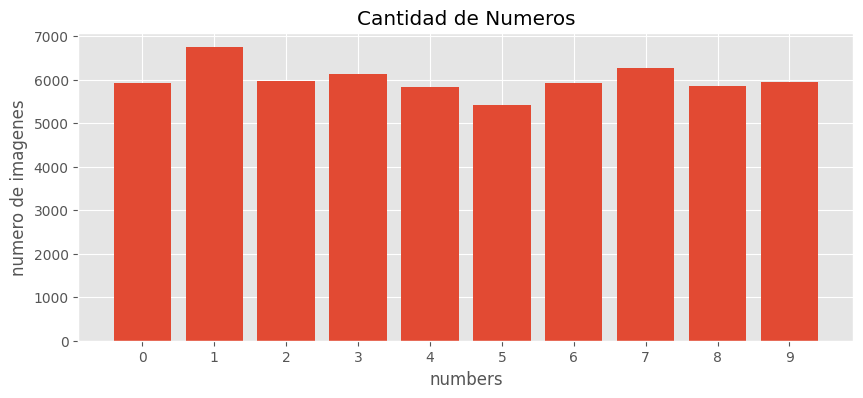

In [12]:
value_train, count_train = np.unique(y_train, return_counts=True)
#grafico
plt.figure(figsize=(10,4))#tamaño del grafico
plt.bar(value_train, count_train)#traemos lo de value
plt.title("Cantidad de Numeros")#titulo
plt.xlabel("numbers")
plt.ylabel("numero de imagenes")
plt.xticks(value_train)#mostrar de 0 al 9
plt.show()

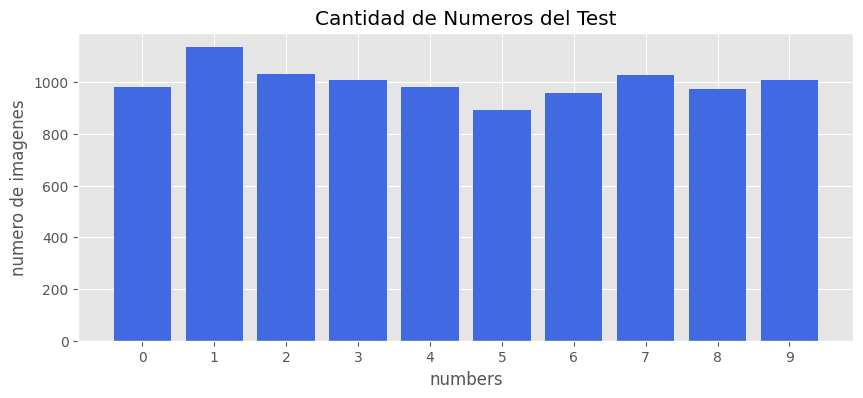

In [14]:
value_test, count_test = np.unique(y_test, return_counts=True)
#grafico
plt.figure(figsize=(10,4))#tamaño del grafico
plt.bar(value_test, count_test, color="royalblue")#traemos lo de value
plt.title("Cantidad de Numeros del Test")#titulo
plt.xlabel("numbers")
plt.ylabel("numero de imagenes")
plt.xticks(value_train)#mostrar de 0 al 9
plt.show()

In [15]:
train_imagen = X_train.reshape(60000, 28, 28, 1)
train_imagen = train_imagen.astype("float32")/255
test_imagen = X_test.reshape(10000, 28, 28, 1)
test_imagen = test_imagen.astype("float32")/255

In [16]:
train_imagen[20]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [17]:
train_imagen.shape


(60000, 28, 28, 1)

In [18]:
from keras.utils import to_categorical
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)

In [21]:
train_labels[3000]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

ARQUITECTURA DE MI RED

In [25]:
from keras.src.models import model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten

model = Sequential([
    Input(shape=(28,28,1)),
    Dense(64, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28, 28, 64)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28, 28, 64)     │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28, 28, 10)     │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,938 (19.29 KB)

 Trainable params: 4,938 (19.29 KB)

 Non-trainable params: 0 (0.00 B)